In [10]:
# Hypergraph Class

# hypergraphs are directly initiated through a set of nodes and a dictionary with edges as keys and sets of nodes as objects
from Hypergraph import hypergraph

H = hypergraph(
    {0, 1, 2, 3}, # set of nodes
    {0: {0, 1}, 1: {0, 2}, 2: {1, 2, 3}}
)

# printing a hypgraph will just print the dictionary with hyperedges as keys and the nodes they contain in a set as objects

print("Hypergraph H:", H)

# Nodes and edges can also be added to hypergraphs

G = hypergraph() # putting in no inputs results in an empty hypergraph
print("Label of new node added to G:", G.add_node()) # don't specify a number here, that will be done automatically
# if you want to connect that node to existing edges, input a set of edges in the add node function
# nonexistent hyperedges in this set will be added automatically
# the add_node method returns the numeric label of the new node so that it can be direcly acessed

# note that adding edges with nonexistant nodes will cause that node to be automatically created
print("Label of new hyperedge added to G:", G.add_edge({0, 1})) # returns the numeric label of the new edge
print("Label of new hyperedge added to G:", G.add_edge({1, 2}))
G.add_edge({0, 2})
G.add_edge({2, 3, 4})

print("Hypergraph G:", G)



Hypergraph H: {0: {0, 1}, 1: {0, 2}, 2: {1, 2, 3}}
Label of new node added to G: 0
Label of new hyperedge added to G: 0
Label of new hyperedge added to G: 1
Hypergraph G: {0: {0, 1}, 1: {1, 2}, 2: {0, 2}, 3: {2, 3, 4}}


In [11]:
# immersion

# there are three main immersion methods:
# brute_force_immersion: the slowest (brute forces every possible hyperedge mapping)
# immersion: the first version of the optimized immersion function
# quick_immersion: the fastest immersion method so far, a successor to the immersion (from above)

from Brute_force_immersion import brute_force_immersion
from Immersion import immersion
from Quick_immersion import quick_immersion

# All three immersion functions are classes and can be executed the following way

Brute_force = brute_force_immersion(
    G, # what you're immersing onto
    H  # what you're trying to immerse
)
Brute_force.immerse() # returns None

print("Immersion found by brute_force_immersion class:", len(Brute_force.immersions) > 0)



Regular_immersion = immersion(G, H)
print("Immersion found by immersion class:", Regular_immersion.immerse(use_random_priority = False)) # two ways getting the priority
# one way is just to pick an edge, then pick one next to it and so on, the other uses a higharchy system related to size and connectivity
# this immerse opperation returns True if an immersion was found and false if not


fast_immersion = quick_immersion(G, H, max_depth = None, use_random_priority = False) # max depth is the max allowed edge mergers
# decreasing this peramiter will make the opperation less thorough but signifigantly faster
print("Immersion found by qiuck_immersion class:", fast_immersion.execute(show_end_condition = True, depth = 0, amount = 100))
# show end condition (if true) will show what the end condition was
# the end condition is when a ceartian amount of distinct immersions within a ceartian depth have been found
# these thresholds are determined by the depth and amount paramiter


Immersion found by brute_force_immersion class: True
Immersion found by immersion class: True
Ended by going through all possibilities
Immersion found by qiuck_immersion class: True


In [12]:
# immersion function
from Immersion_function import immersion_function

# immersions ares stored in the immersion function class
alpha = fast_immersion.immersions()[0] # just taking the first immersion from the list

print("Immersion function example: ")
print(alpha, "\n") # prints both hypergraphs as well as a dictionary for edge mapping and node mapping

# there is also an evaluation method
print("alpha(node #0) =", alpha.evaluate("node", 0)) # the node in G that node 0 in H maps to
print("alpha(hyperedge #0) =", alpha.evaluate("edge", 0)) # a tuple containing all edges in the connected subgraph of G that hyperedge 0 in H maps to

print()
print("alpha is a proper immersion function:", alpha.is_immersion()) # immersions can be verified, this directly works off of the mathematical definition of an immersion


Immersion function example: 
G: {0: {0, 1}, 1: {1, 2}, 2: {0, 2}, 3: {2, 3, 4}}
H: {0: {0, 1}, 1: {0, 2}, 2: {1, 2, 3}}
Nodes: {0: 0, 1: 1, 2: 2, 3: 3}
Edges: {0: (0,), 1: (2,), 2: (1, 3)} 

alpha(node #0) = 0
alpha(hyperedge #0) = (0,)

alpha is a proper immersion function: True


In [13]:
# creating hypergraphs manually can be quite annoying, so they can also be generated randomly
from Hypergraph_randomizer import hypergraph_ramdomizer

hypergraph_generator = hypergraph_ramdomizer(
    min_node_count = 5,
    max_node_count = 10,
    min_edge_count = 4,
    max_edge_count = 6
)

# the edge and node counts can go below the minimum but will not exceed their maximums
# only loopless hypergraphs will be generated, and no hyperedge will have less than 2 verticies
# all generated hypergraphs will be connected
# there are no duplicate hyperedges
# and every node is in at least 1 edge

random_hypergraph = hypergraph_generator.generate(power = 3, write = True)
# a higher power paramiter will make smaller hyperedges and a more sparcly connected hypergraph
# the write paramiter allows for the hypergraph to be written inside the class and to be accessed in other ways

print("Randomly generated hypergraph:", random_hypergraph)

Randomly generated hypergraph: {0: {0, 1, 2, 3, 4, 5, 6}, 2: {3, 4, 5}, 4: {0, 1, 5}}


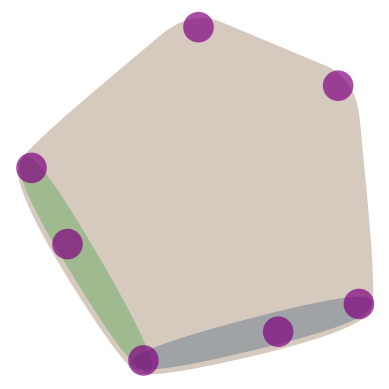


The drawing can be rotated


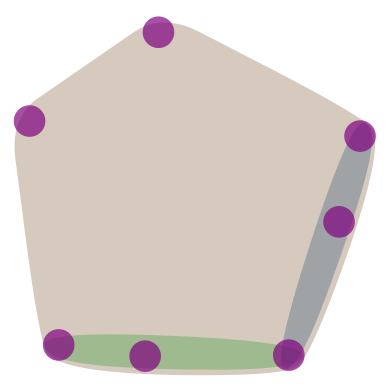

In [14]:
# Drawing

# hypergraphs and immersions can also be drawn automatically

from Drawing import drawing

visual = drawing.draw_hypergraph(random_hypergraph)

visual.show()

# This can be rotated, streached, and offest, where the last two are mainly for displaying multiple drawings at once

visual.rotate(1) # angle in radians

print("\nThe drawing can be rotated")
visual.show()


            Specific Layout Methods:
            (these should be inputted as a string for in the method paramiter for the scatter.layout()))

            "random": 
            a random layout of nodes where each node has a vector of randomized x and y values between -1 and 1

            "factor_graph_spring_layout": 
            spring layout of the factor graph

            "sorted_circle": 
            creates a circle where nodes are sorted in assigment number by angle (around (0, 0) and radius 1))
            
random:


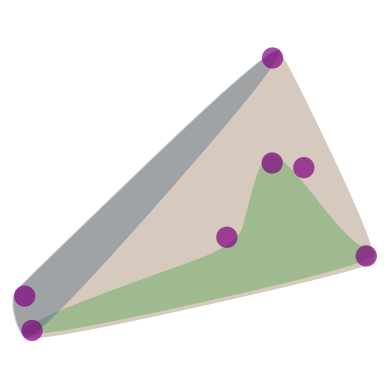

sorted_circle


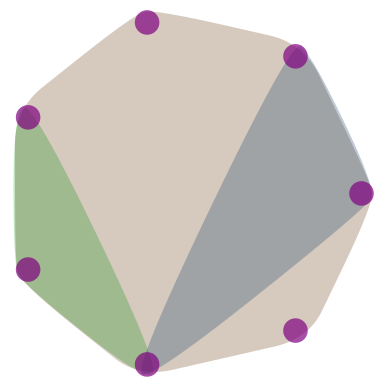

In [15]:
# different layouts can be used for the nodes for the draw_hypergraph and draw_immersion (which ill get to soon) initiation methods

from Scatter import scatter # this is mainly an internal class for organization, but it does contain a guide to all layout methods
scatter.layout_methods() # just call this function and you will get all layout methods printed

print("random:")
drawing.draw_hypergraph(random_hypergraph, layout_method = "random").show() # how to display a hypergraph in just one line

print("sorted_circle")
drawing.draw_hypergraph(random_hypergraph, layout_method = "sorted_circle").show()

Regular Drawing (of H):


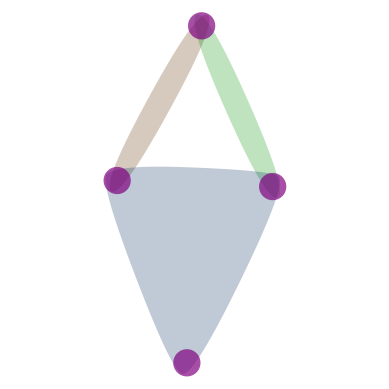

Line Drawing (of G):


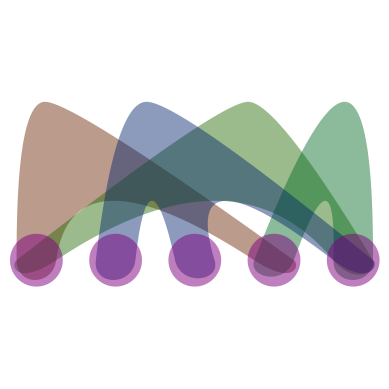

In [16]:
# there are two methods for drawing hypergraphs

print("Regular Drawing (of H):")
drawing.draw_hypergraph(H).show()

print("Line Drawing (of G):")
drawing.line_draw_hypergraph(G).show()

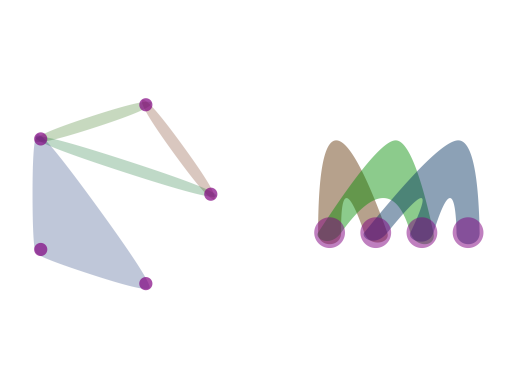

In [17]:
# G and H can be drawn together and bounded 

from Vector import vector # generally internal but you may need it for offsets
v = vector(3, 0) # (x, y) - use ints or floats

H_drawing = drawing.line_draw_hypergraph(H)
G_drawing = drawing.draw_hypergraph(G, layout_method = "sorted_circle")

# automatic bounding
H_drawing.autobound(
    x_min = -1,
    x_max = 1,
    y_min = -1,
    y_max = 1
)

H_drawing.offset(v)

import matplotlib.pyplot as plt
plt.figure()
plt.axis("off")
plt.axis("equal")
G_drawing.plot() # the .plot() method handles all of the plotting of the drawing
H_drawing.plot()
plt.show()

Basic overlay drawing:


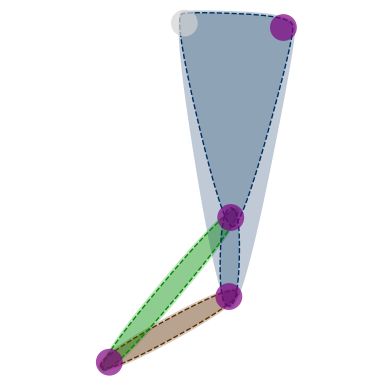


Line-arrow drawing method:


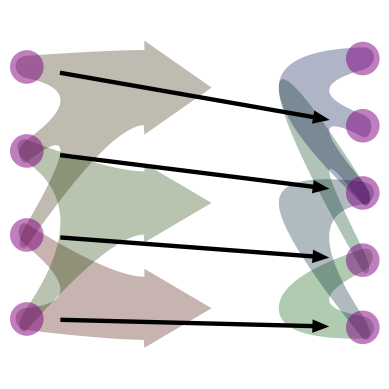

In [18]:
# immersions can also be drawn

# there are two ways to draw them

print("Basic overlay drawing:")
drawing.draw_immersion(alpha).show() # the layout method can also be adjusted in this

print()
print("Line-arrow drawing method:")
drawing.line_draw_immersion(alpha,
                            arrow_thickness = 0.065,
                            arrowhead_width = 0.2,
                            saturation = 0.35,
                            edge_opacity = 0.31,
                            node_radius = 1/4
                            ).show()

# these drawing methods have alot of adjustable paramiters, so feel free to play around, if an error is produced, or something
# weird is made, it's likely a result of a paramiter being outside of the intended bounds
# feel free to ask any questions


# all classes not mentioned here do serve a purpose in the internal functionality of everything, however, they don't really need to be
# interacted with directly

# feel free to let me know if some unexpected errors come up as it is possible there is a mistake laying around somewhere that
# I haven't found yet